In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import sigmaclip, kurtosis

In [3]:
data = pd.read_csv("refit_output/merged_refit.csv")
data

,KIC,nu_max,H,P,tau,alpha,W,success,status,e_nu_max:nu_max,...,e_P:P,e_P:tau,e_P:alpha,e_P:W,e_tau:tau,e_tau:alpha,e_tau:W,e_alpha:alpha,e_alpha:W,e_W:W
0,757137,30.371125,6058.370125,18847.571573,10541.864240,3.230190,20.264146,True,0,0.018407,...,3.514842e+05,1.228374e+05,-11.526866,-24.160508,7.259875e+04,-9.522139,-22.072794,0.001476,0.004078,0.043349
1,892010,17.269038,23923.003728,76037.425479,15907.483669,3.493330,66.400073,True,0,0.088775,...,6.121225e+07,6.970402e+06,-429.911166,-1157.215057,1.292534e+06,-114.412661,-404.384963,0.012407,0.054173,1.462816
2,892738,7.317599,193201.119487,389277.168839,34733.038187,3.388868,161.599341,True,0,0.005086,...,5.138732e+08,1.978013e+07,-338.866406,-2892.940933,1.311985e+06,-42.987726,-403.369313,0.001979,0.020620,1.286137
3,892760,29.600306,20102.123292,66062.793128,13299.975476,2.721107,527.377142,True,0,0.033272,...,1.146116e+07,1.707225e+06,-107.769119,-3807.075893,3.644830e+05,-30.038706,-1050.132530,0.003151,0.141083,31.421144
4,893214,40.237823,3263.029766,14210.758589,12981.767232,2.536509,64.519327,True,0,0.024806,...,3.088559e+05,1.921747e+05,-8.638990,-85.368183,1.618939e+05,-10.028795,-94.550440,0.000883,0.011147,0.493522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12461,12884930,37.397225,7186.035098,24337.886899,12411.623172,2.566214,145.979333,True,0,0.024474,...,9.790291e+05,3.622655e+05,-20.382464,-294.848862,1.823638e+05,-13.235179,-182.141856,0.001267,0.025700,2.340377
12462,12885005,28.482534,26613.790644,78633.331419,12425.893047,2.895537,439.360452,True,0,0.020896,...,1.023190e+07,1.151831e+06,-82.887739,-1796.741364,1.930310e+05,-18.524647,-422.483190,0.002226,0.072852,15.368899
12463,12885196,89.439522,778.189214,5383.583288,8470.503186,2.048380,78.776364,True,0,0.077837,...,3.496301e+04,4.807602e+04,-3.646307,-91.245850,8.529965e+04,-8.519079,-211.430805,0.001332,0.043622,2.369461
12464,12885373,51.398211,2984.375214,11551.025774,9832.195841,2.623390,40.159777,True,0,0.026979,...,1.358104e+05,7.831758e+04,-5.217454,-31.953429,6.454599e+04,-5.988680,-34.182883,0.000766,0.006614,0.229135


In [4]:
data["success"].sum() / len(data)

0.9951066901973368

In [5]:
data.columns

Index(['KIC', 'nu_max', 'H', 'P', 'tau', 'alpha', 'W', 'success', 'status',
       'e_nu_max:nu_max', 'e_nu_max:H', 'e_nu_max:P', 'e_nu_max:tau',
       'e_nu_max:alpha', 'e_nu_max:W', 'e_H:H', 'e_H:P', 'e_H:tau',
       'e_H:alpha', 'e_H:W', 'e_P:P', 'e_P:tau', 'e_P:alpha', 'e_P:W',
       'e_tau:tau', 'e_tau:alpha', 'e_tau:W', 'e_alpha:alpha', 'e_alpha:W',
       'e_W:W'],
      dtype='object')

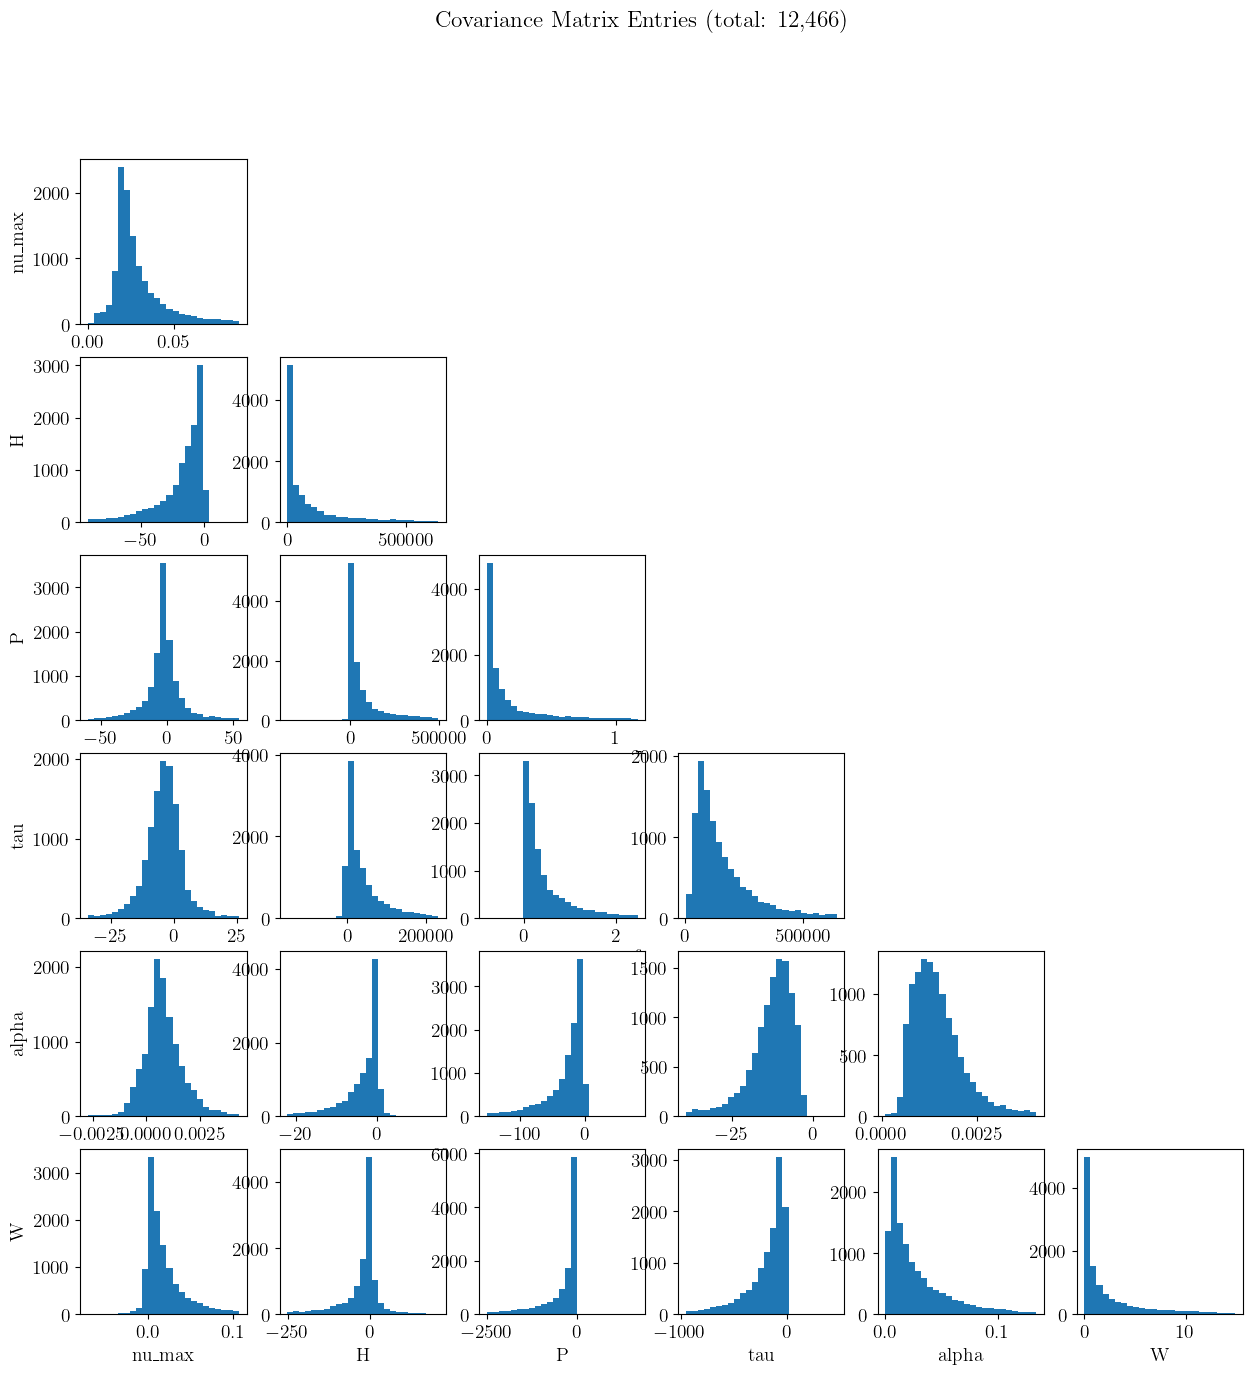

In [ ]:
PARAM_NAMES = ("nu_max", "H", "P", "tau", "alpha", "W")

fig = plt.figure(figsize=(15, 15))
fig.suptitle(f"Covariance Matrix Entries (total: {len(data):,})")

for col_idx, f_param_name in enumerate(PARAM_NAMES):
    for row_idx, s_param_name in enumerate(PARAM_NAMES[col_idx:], start = col_idx):
        plot_index = (row_idx * len(PARAM_NAMES)) + col_idx + 1
        ax = fig.add_subplot(len(PARAM_NAMES), len(PARAM_NAMES), plot_index)
        if col_idx == 0:
            ax.set_ylabel(s_param_name)
        if row_idx == len(PARAM_NAMES) - 1:
            ax.set_xlabel(f_param_name)
        
        covs = data[f"e_{f_param_name}:{s_param_name}"].values
        covs = sigmaclip(covs).clipped
        
        ax.hist(covs, bins=25)
        # ax.set_yscale("log")

looks reasonable ish?